In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置字体为SimHei（黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决坐标轴负号显示问题
plt.rcParams['axes.unicode_minus'] = False

In [75]:
train_data = pd.read_csv('./data/train.csv')
test_data = pd.read_csv('./data/test.csv')

In [76]:
train_data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,187,37,125591,2013-08-08,IN,500/1000,1000,1412.06,5000000,450947,...,?,57700,5770,5770,46160,Nissan,Maxima,2000,0,NaN
1,243,44,967713,1997-12-25,IL,250/500,500,809.11,0,600208,...,YES,51400,5140,10280,35980,Honda,Civic,1996,0,NaN
2,24,33,649082,1996-01-19,IL,500/1000,1000,1922.84,0,431277,...,NO,46800,4680,9360,32760,Jeep,Wrangler,2002,0,NaN
3,215,42,519312,2008-10-28,OH,500/1000,500,1848.81,0,435489,...,YES,68520,11420,5710,51390,Suburu,Legacy,2003,1,NaN
4,85,30,190588,2001-12-09,OH,100/300,1000,796.35,0,614166,...,YES,58960,5360,10720,42880,Ford,F150,2004,0,NaN


In [77]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           700 non-null    int64  
 1   age                          700 non-null    int64  
 2   policy_number                700 non-null    int64  
 3   policy_bind_date             700 non-null    str    
 4   policy_state                 700 non-null    str    
 5   policy_csl                   700 non-null    str    
 6   policy_deductable            700 non-null    int64  
 7   policy_annual_premium        700 non-null    float64
 8   umbrella_limit               700 non-null    int64  
 9   insured_zip                  700 non-null    int64  
 10  insured_sex                  700 non-null    str    
 11  insured_education_level      700 non-null    str    
 12  insured_occupation           700 non-null    str    
 13  insured_hobbies              70

In [78]:
# ===== 1. 数据基本信息 =====
print("="*50)
print("数据集基本信息")
print("="*50)
print(f"训练集形状: {train_data.shape}")
print(f"测试集形状: {test_data.shape}")
print(f"\n列名列表:\n{train_data.columns.tolist()}")
print(f"\n数据类型:\n{train_data.dtypes}")


数据集基本信息
训练集形状: (700, 40)
测试集形状: (300, 39)

列名列表:
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']

数据类型:
months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                   str
policy_state                       str
pol


缺失值分析
                       缺失数     缺失比例(%)
_c39                   700  100.000000
authorities_contacted   60    8.571429

总缺失值数: 760


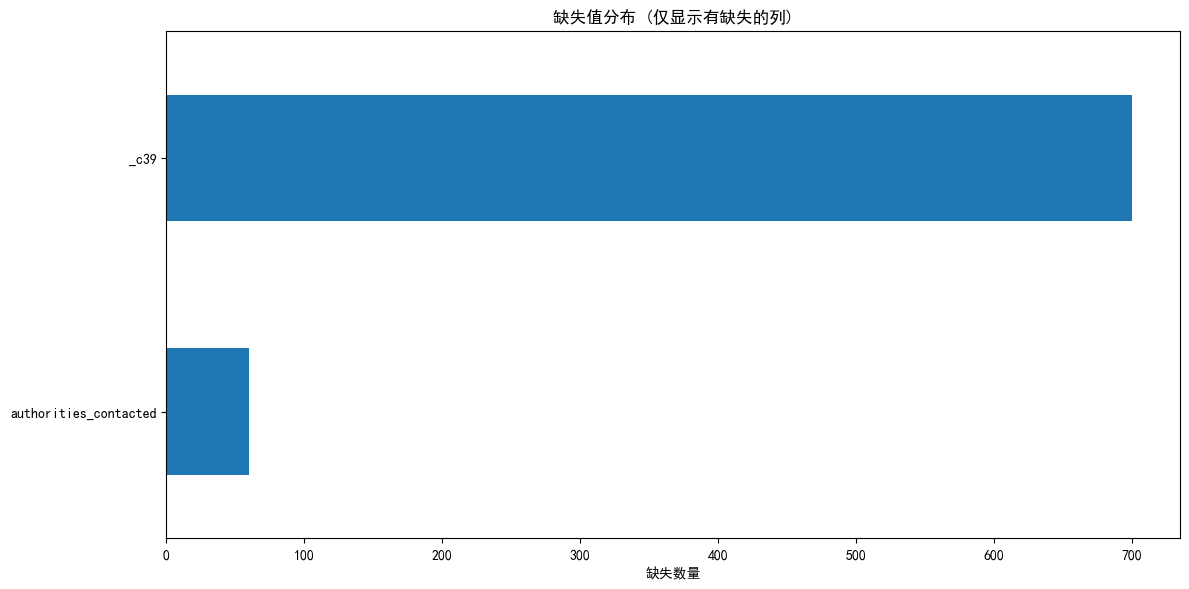

In [79]:
# ===== 2. 缺失值分析 =====
print("\n" + "="*50)
print("缺失值分析")
print("="*50)
missing_values = train_data.isnull().sum()
missing_percent = (train_data.isnull().sum() / len(train_data)) * 100
missing_df = pd.DataFrame({
    '缺失数': missing_values,
    '缺失比例(%)': missing_percent
})
missing_df = missing_df[missing_df['缺失数'] > 0].sort_values('缺失数', ascending=False)
print(missing_df)
print(f"\n总缺失值数: {train_data.isnull().sum().sum()}")

# 缺失值可视化
fig, ax = plt.subplots(figsize=(12, 6))
missing_data = train_data.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    missing_data.plot(kind='barh', ax=ax)
    ax.set_title('缺失值分布 (仅显示有缺失的列)')
    ax.set_xlabel('缺失数量')
    plt.tight_layout()
    plt.show()
else:
    print("无缺失值!")


In [80]:
# ===== 3. 数值特征统计分析 =====
print("\n" + "="*50)
print("数值特征统计信息")
print("="*50)
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
print(train_data[numeric_cols].describe().T)


数值特征统计信息
                             count          mean           std         min  \
months_as_customer           700.0  2.058943e+02  1.160187e+02        0.00   
age                          700.0  3.910571e+01  9.166258e+00       20.00   
policy_number                700.0  5.492421e+05  2.584805e+05   100804.00   
policy_deductable            700.0  1.147857e+03  6.115797e+02      500.00   
policy_annual_premium        700.0  1.245976e+03  2.483109e+02      433.33   
umbrella_limit               700.0  1.100000e+06  2.282922e+06 -1000000.00   
insured_zip                  700.0  5.014326e+05  7.221025e+04   430104.00   
capital-gains                700.0  2.580486e+04  2.804340e+04        0.00   
capital-loss                 700.0 -2.622800e+04  2.842299e+04  -111100.00   
incident_hour_of_the_day     700.0  1.164286e+01  6.964524e+00        0.00   
number_of_vehicles_involved  700.0  1.870000e+00  1.035265e+00        1.00   
bodily_injuries              700.0  9.942857e-01  8.18

In [81]:
# ===== 4. 分类特征分析 =====
print("\n" + "="*50)
print("分类特征信息")
print("="*50)
categorical_cols = train_data.select_dtypes(include=['object']).columns
print(f"分类特征数: {len(categorical_cols)}")
print(f"分类特征列表: {categorical_cols.tolist()}\n")

for col in categorical_cols:
    print(f"\n{col} - 唯一值数: {train_data[col].nunique()}")
    print(train_data[col].value_counts().head(10))


分类特征信息
分类特征数: 20
分类特征列表: ['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


policy_bind_date - 唯一值数: 673
policy_bind_date
1997-02-03    2
2006-01-01    2
1997-07-14    2
1992-08-05    2
2002-12-28    2
1995-12-07    2
1991-12-14    2
2004-08-09    2
2003-03-09    2
1991-07-20    2
Name: count, dtype: int64

policy_state - 唯一值数: 3
policy_state
OH    249
IL    237
IN    214
Name: count, dtype: int64

policy_csl - 唯一值数: 3
policy_csl
100/300     259
250/500     248
500/1000    193
Name: count, dtype: int64

insured_sex - 唯一值数: 2
insured_sex
FEMALE    370
MALE      330
Name: count, dtype: int64

insured_education_level - 唯一值数: 7
insured_education_level
JD     

C:\Users\HP\AppData\Local\Temp\ipykernel_7560\3722028944.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data.select_dtypes(include=['object']).columns


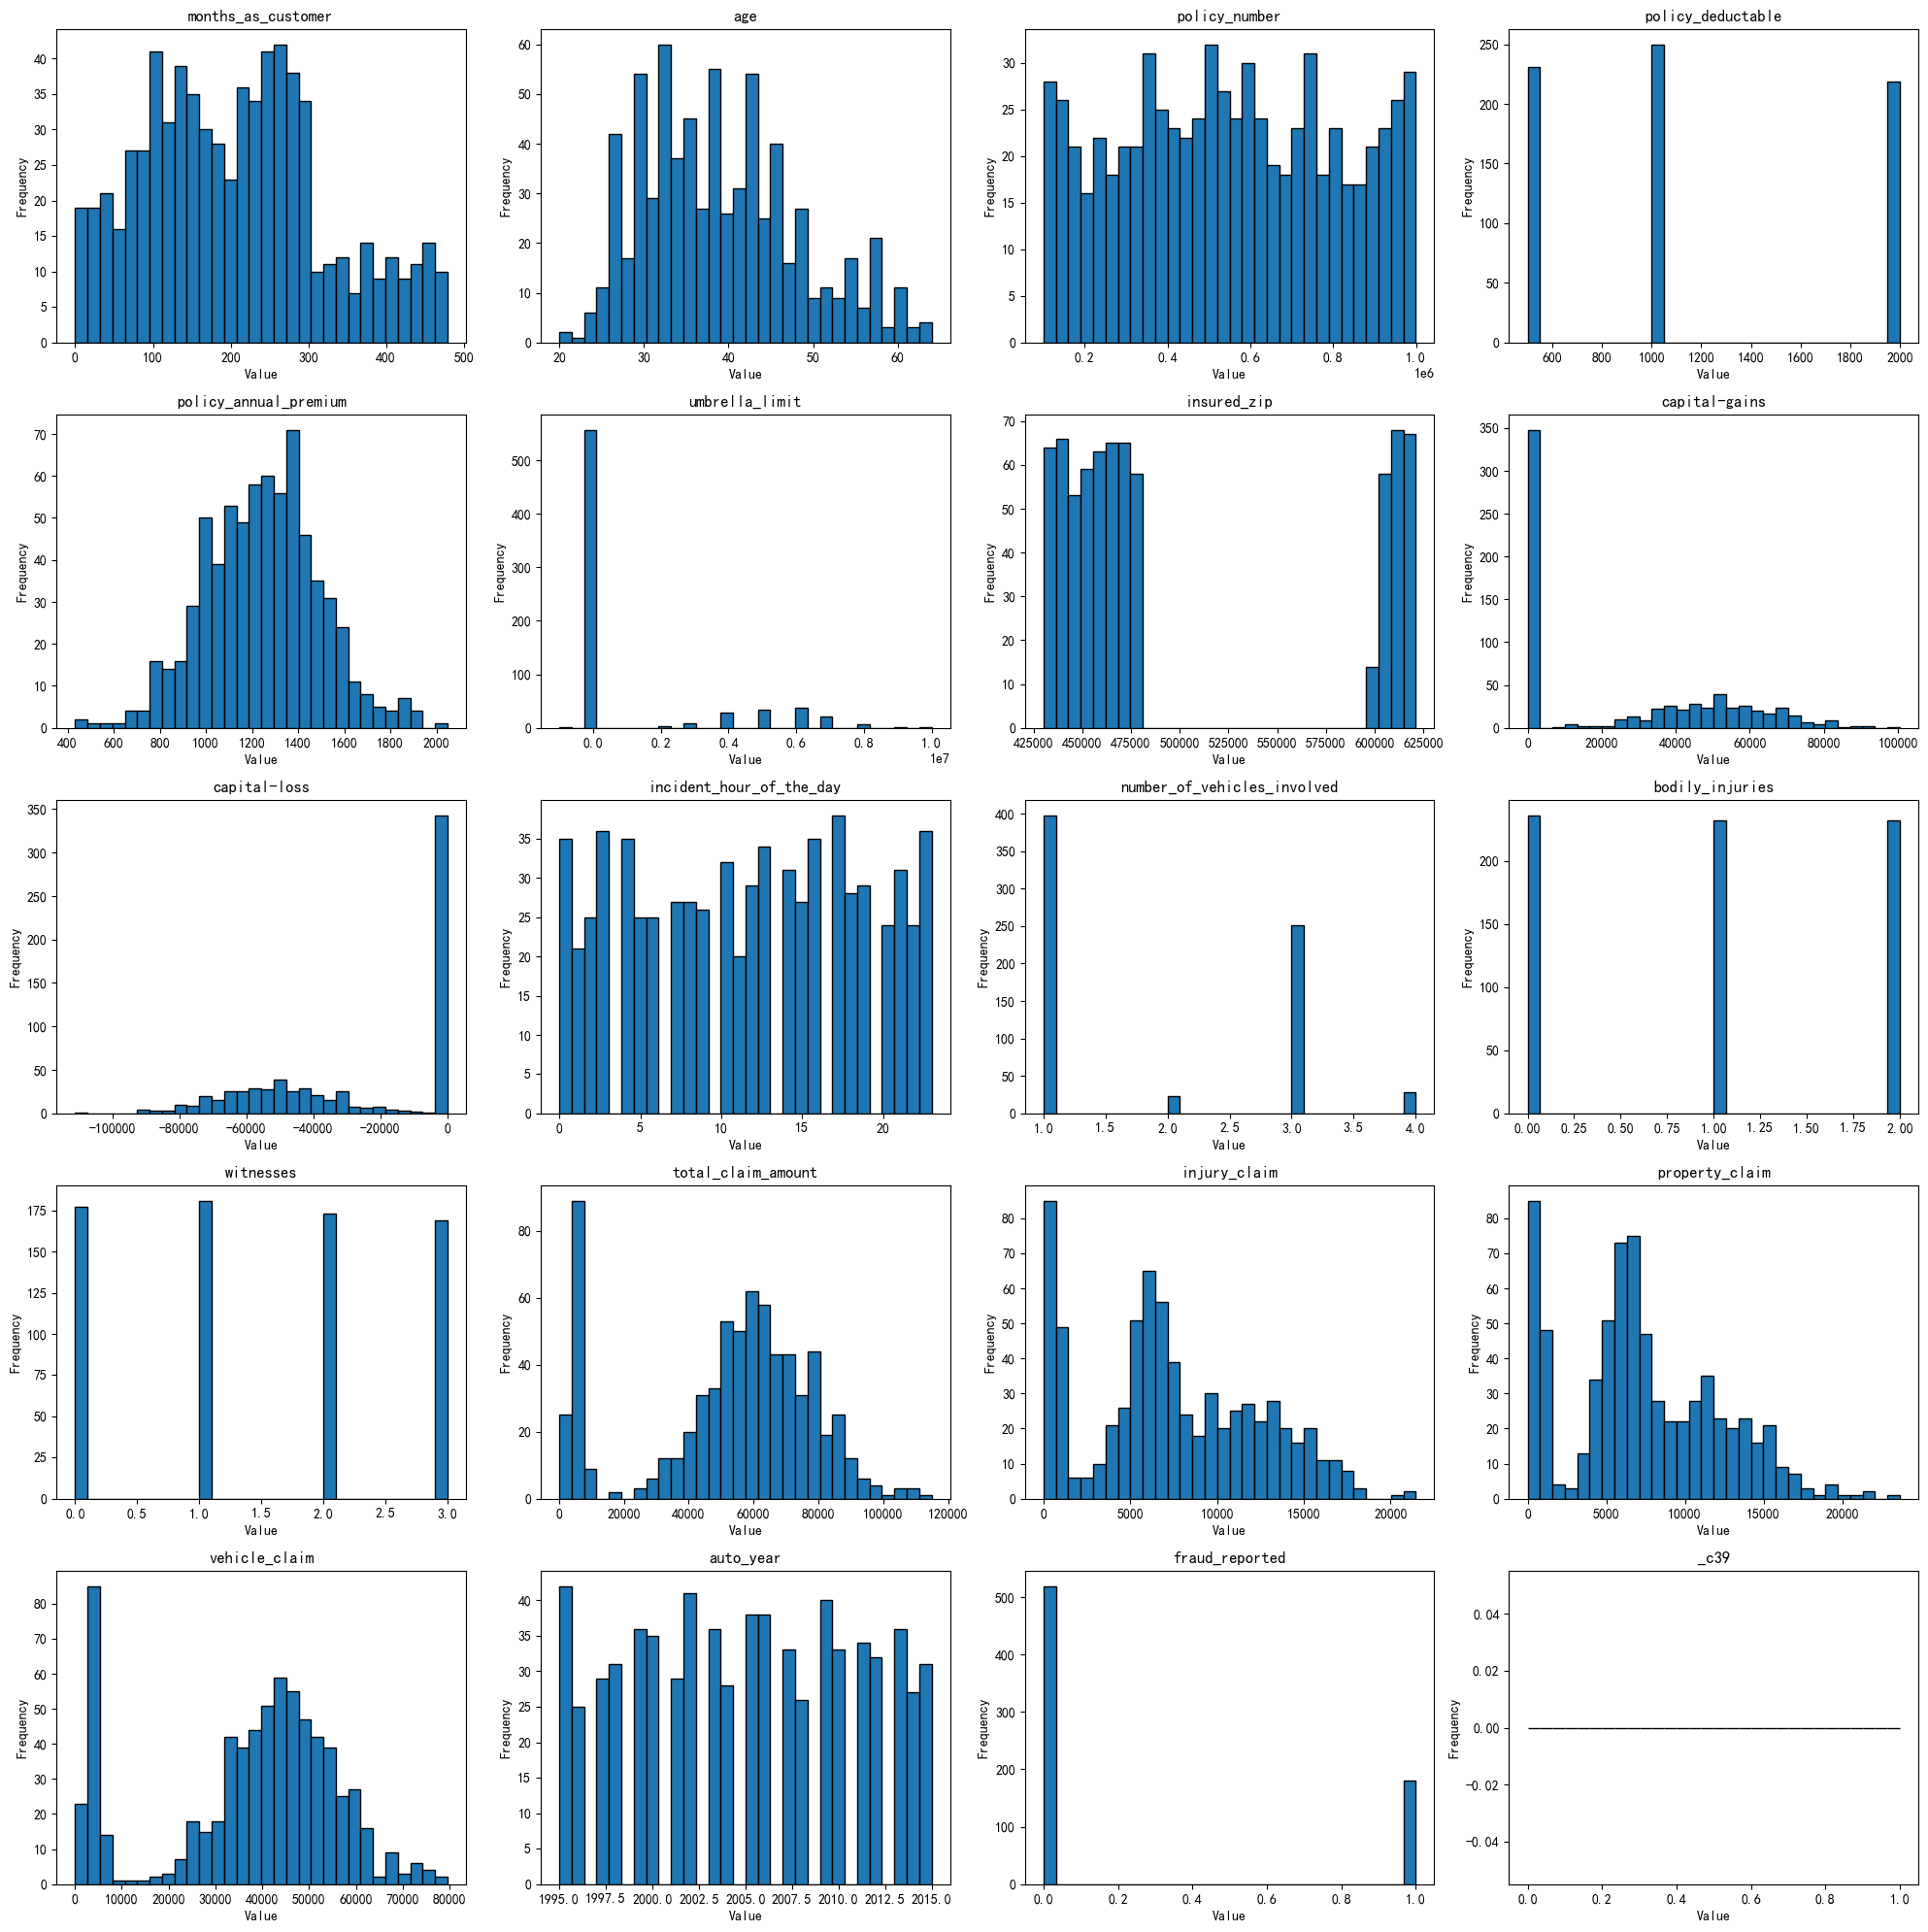

In [82]:
# ===== 5. 数值特征分布可视化 =====
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(train_data[col].dropna(), bins=30, edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# 隐藏多余的子图
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_7560\2121593418.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data.select_dtypes(include=['object']).columns


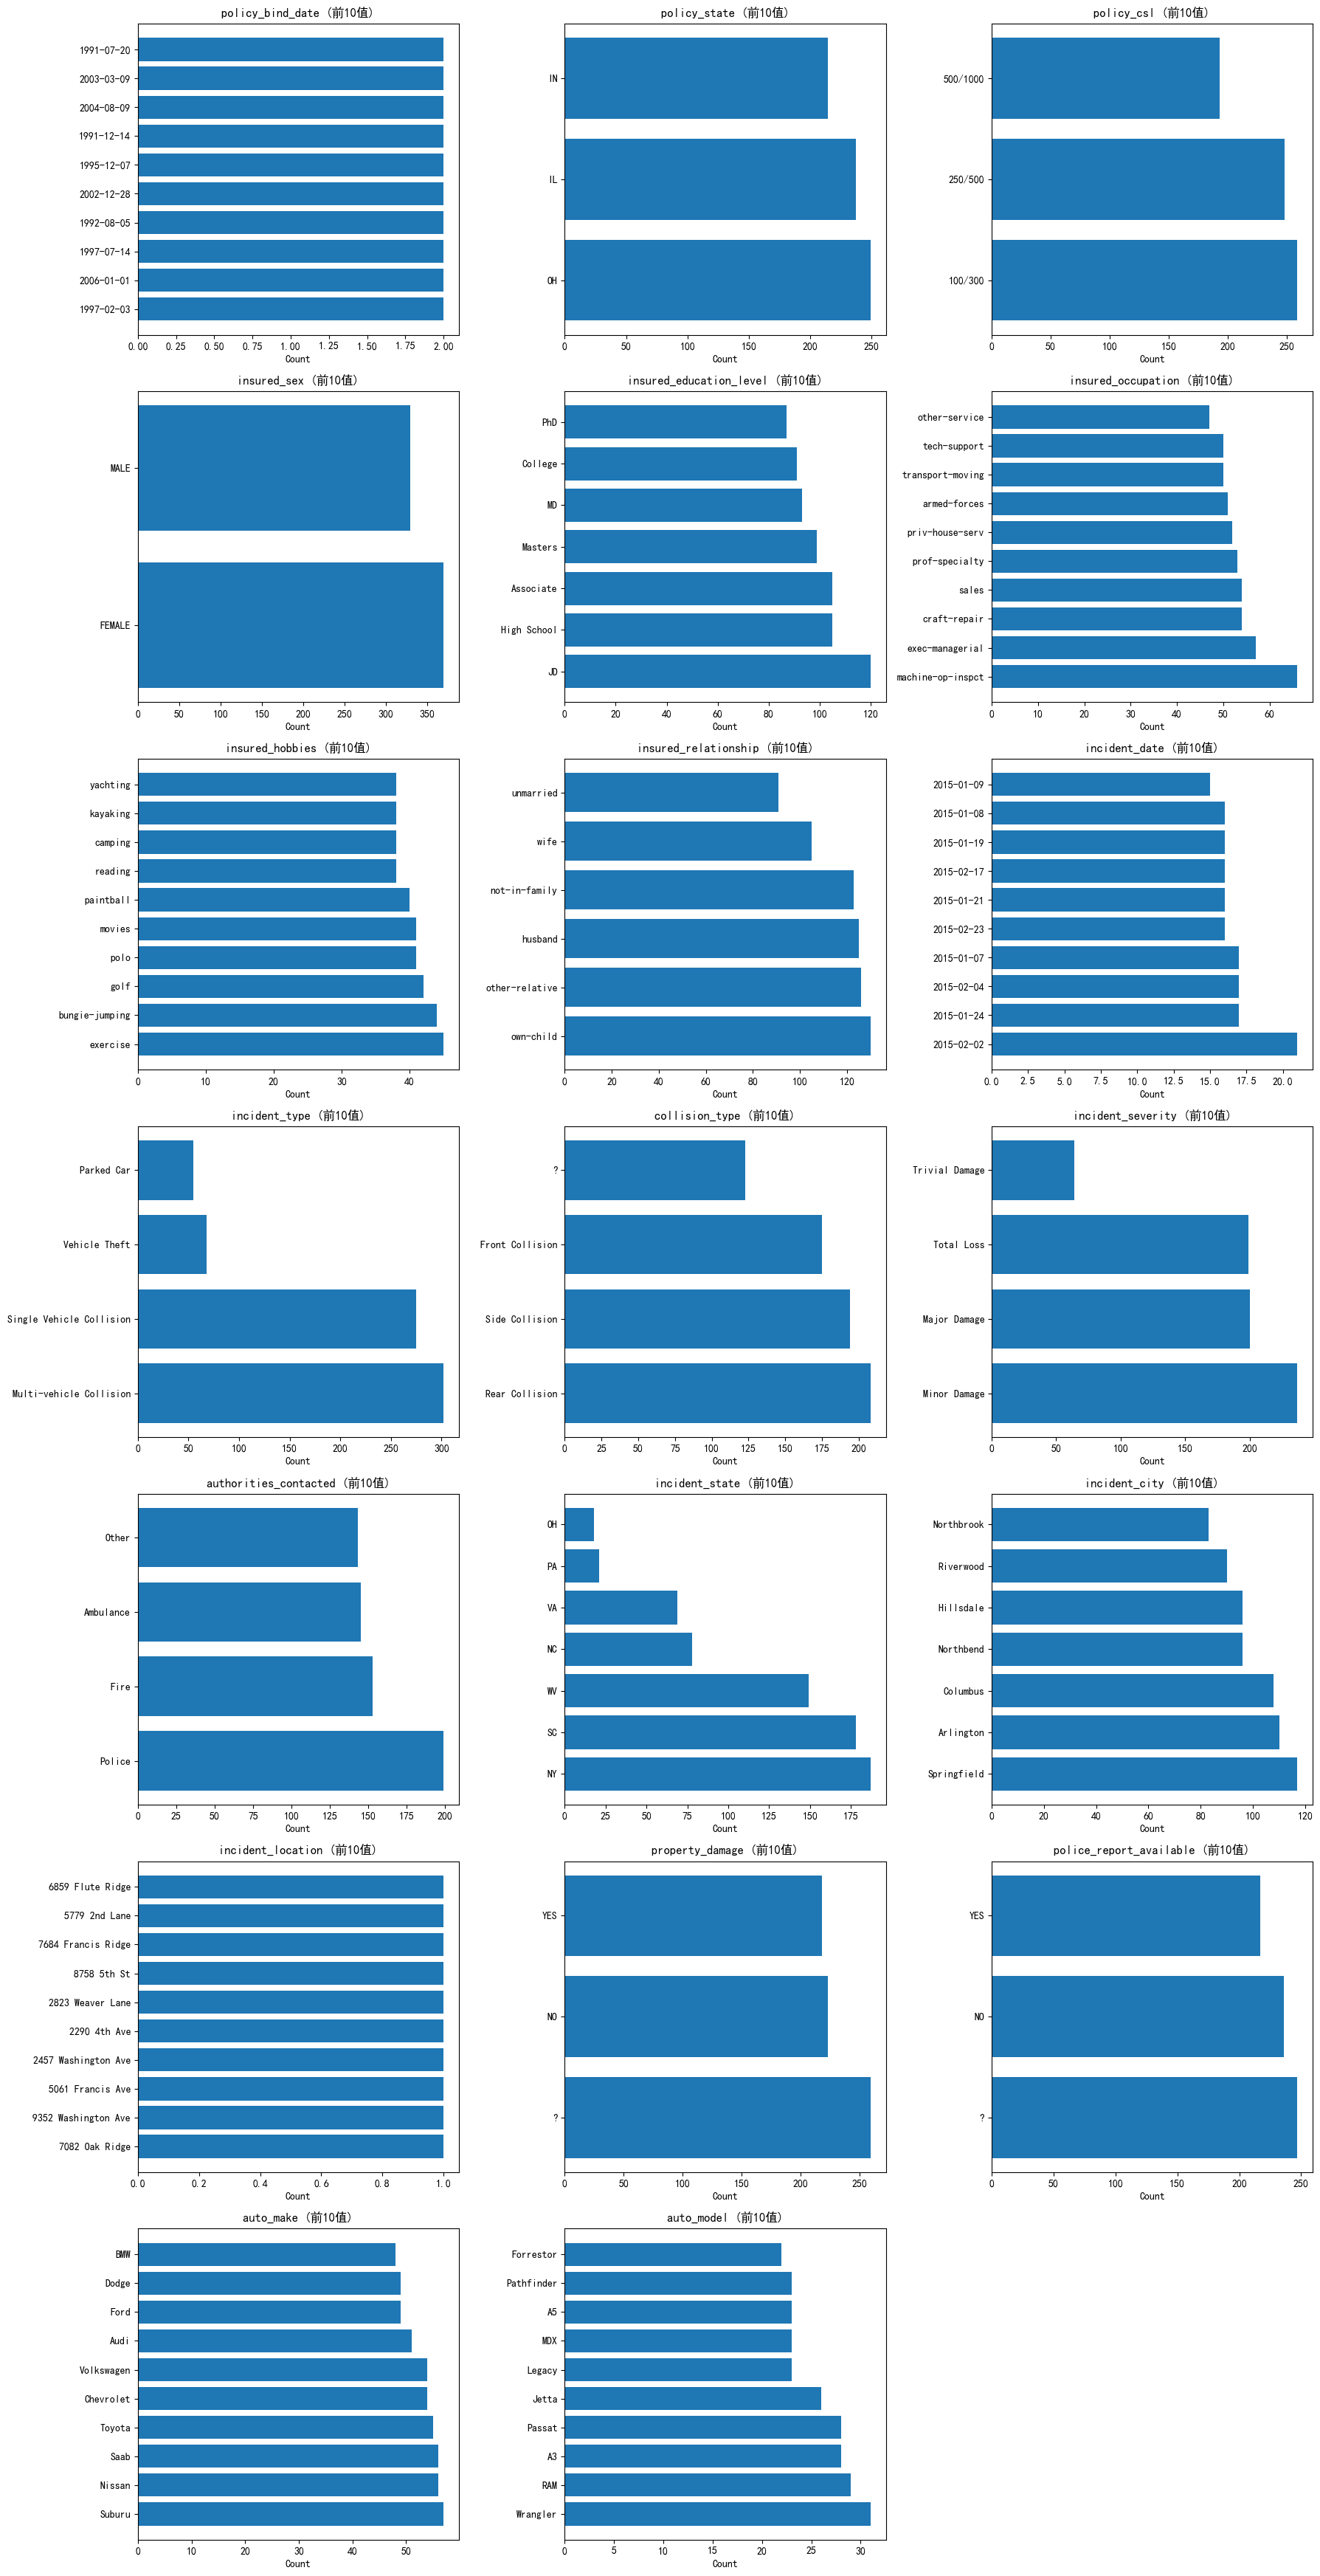

In [83]:
# ===== 6. 分类特征分布可视化 =====
categorical_cols = train_data.select_dtypes(include=['object']).columns
n_cols = len(categorical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*5))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = train_data[col].value_counts()
    # 只显示前10个分类
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)
    
    axes[idx].barh(range(len(value_counts)), value_counts.values)
    axes[idx].set_yticks(range(len(value_counts)))
    axes[idx].set_yticklabels(value_counts.index)
    axes[idx].set_title(f'{col} (前10值)')
    axes[idx].set_xlabel('Count')

# 隐藏多余的子图
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()



数值特征相关性矩阵


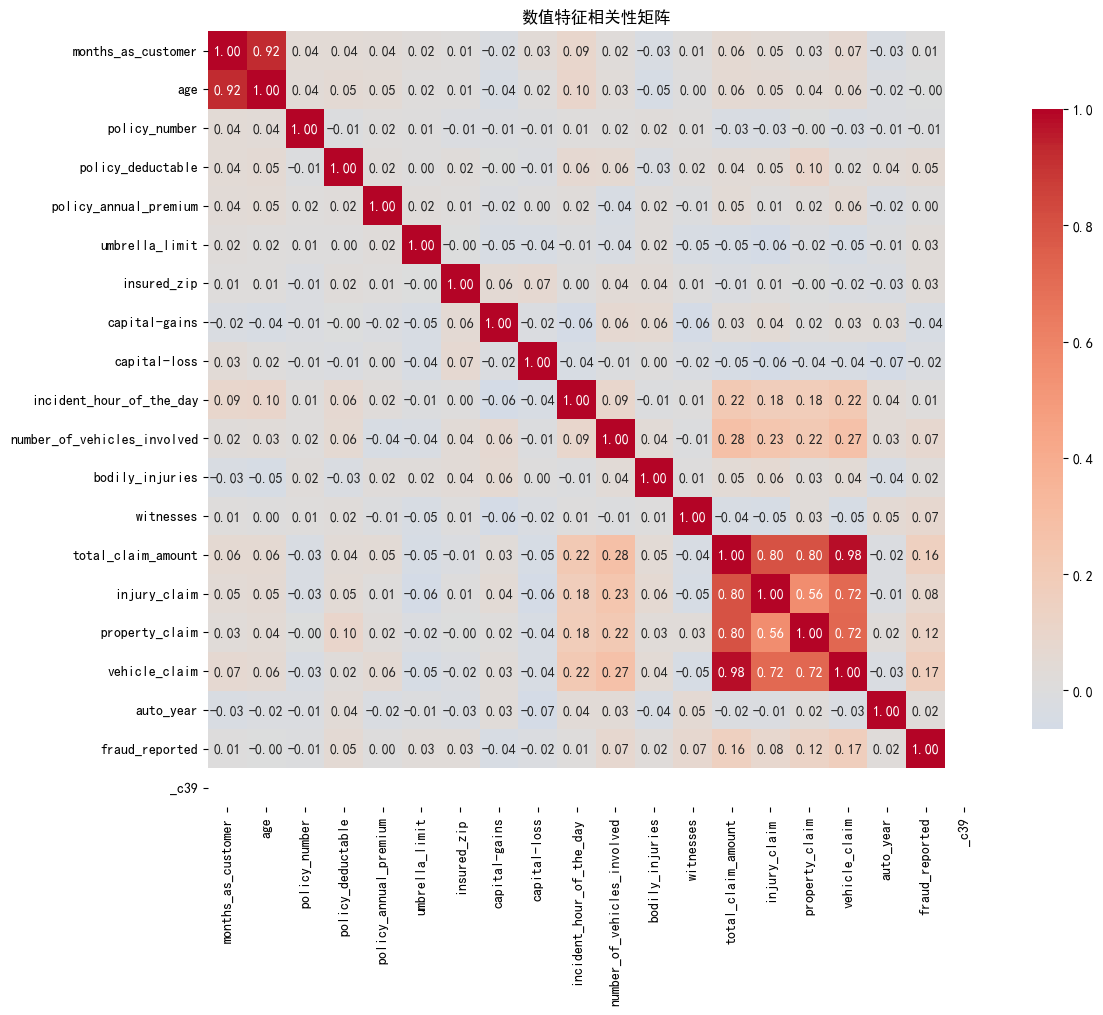

In [84]:
# ===== 7. 特征相关性分析 =====
print("\n" + "="*50)
print("数值特征相关性矩阵")
print("="*50)
numeric_df = train_data.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# 可视化相关性热力图
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('数值特征相关性矩阵')
plt.tight_layout()
plt.show()

# 显示与目标变量的相关性（如果目标变量存在）
if 'fraud' in train_data.columns:
    target_corr = correlation_matrix['fraud'].sort_values(ascending=False)
    print("\n与目标变量(fraud)的相关性:")
    print(target_corr)


In [85]:
# ===== 8. 目标变量和异常值分析 =====
# 检查目标变量
if 'fraud' in train_data.columns:
    print("\n" + "="*50)
    print("目标变量(fraud)分布")
    print("="*50)
    fraud_counts = train_data['fraud'].value_counts()
    print(fraud_counts)
    print(f"\n欺诈比例: {fraud_counts[1]/len(train_data)*100:.2f}%")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # 计数图
    fraud_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_title('目标变量分布')
    axes[0].set_xlabel('fraud')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)
    
    # 饼图
    axes[1].pie(fraud_counts.values, labels=['Normal', 'Fraud'], autopct='%1.1f%%',
                colors=['green', 'red'])
    axes[1].set_title('目标变量比例')
    
    plt.tight_layout()
    plt.show()

# 异常值检测
print("\n" + "="*50)
print("异常值检测 (IQR方法)")
print("="*50)
numeric_df = train_data.select_dtypes(include=['int64', 'float64'])
for col in numeric_df.columns:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} 个异常值")



异常值检测 (IQR方法)
policy_annual_premium: 9 个异常值
umbrella_limit: 143 个异常值
total_claim_amount: 1 个异常值
property_claim: 4 个异常值


In [86]:
# ===== 9. 缺失值处理 =====
print("\n" + "="*50)
print("缺失值处理")
print("="*50)

# 1. 删除完全为空的列 (_c39)
if '_c39' in train_data.columns:
    print("删除完全缺失的列: _c39")
    train_data = train_data.drop(columns=['_c39'])
    test_data = test_data.drop(columns=['_c39'])
else:
    print("列 _c39 不存在或已删除")

# 2. 处理 authorities_contacted 列（部分缺失）
if 'authorities_contacted' in train_data.columns:
    print(f"\n处理 authorities_contacted 列")
    missing_count = train_data['authorities_contacted'].isna().sum()
    print(f"缺失值数: {missing_count}")
    if missing_count > 0:
        # 用众数填充
        mode_value = train_data['authorities_contacted'].mode()[0]
        print(f"众数值: {mode_value}")
        train_data['authorities_contacted'] = train_data['authorities_contacted'].fillna(mode_value)
        test_data['authorities_contacted'] = test_data['authorities_contacted'].fillna(mode_value)
        print(f"✓ 已用众数值填充")

# 3. 检查其他列的缺失值
remaining_missing = train_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(f"\n其他缺失值:\n{remaining_missing}")
else:
    print("\n✓ 所有缺失值已处理！")

print(f"\n处理后训练集形状: {train_data.shape}")
print(f"处理后测试集形状: {test_data.shape}")



缺失值处理
删除完全缺失的列: _c39

处理 authorities_contacted 列
缺失值数: 60
众数值: Police
✓ 已用众数值填充

✓ 所有缺失值已处理！

处理后训练集形状: (700, 39)
处理后测试集形状: (300, 38)



异常值处理 (IQR方法)
policy_annual_premium: 9 个异常值 -> 已用中位数(1252.28)替换
umbrella_limit: 143 个异常值 -> 已用中位数(0.00)替换
total_claim_amount: 1 个异常值 -> 已用中位数(57710.00)替换
property_claim: 4 个异常值 -> 已用中位数(6685.00)替换

共处理 4 个特征的异常值


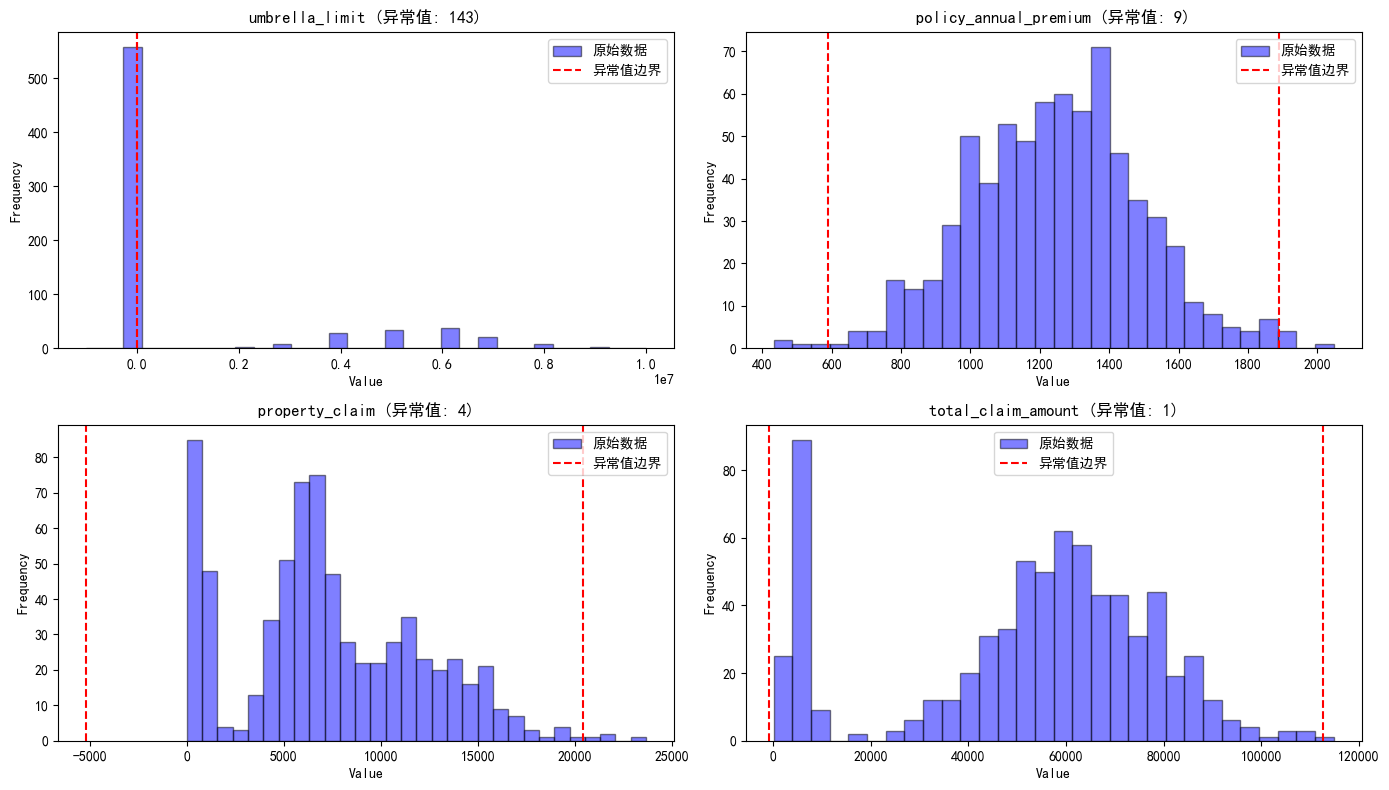

In [87]:
# ===== 10. 异常值处理 =====
print("\n" + "="*50)
print("异常值处理 (IQR方法)")
print("="*50)

# 主要处理策略：用中位数替换异常值
numeric_df = train_data.select_dtypes(include=['int64', 'float64'])
outliers_handled = {}

for col in numeric_df.columns:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 检测异常值
    outlier_mask = (train_data[col] < lower_bound) | (train_data[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    
    if outlier_count > 0:
        outliers_handled[col] = outlier_count
        # 用中位数替换异常值
        median_value = train_data[col].median()
        train_data.loc[outlier_mask, col] = median_value
        print(f"{col}: {outlier_count} 个异常值 -> 已用中位数({median_value:.2f})替换")

if outliers_handled:
    print(f"\n共处理 {len(outliers_handled)} 个特征的异常值")
else:
    print("\n无异常值处理")

# 可视化处理前后对比
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 选择异常值最多的4个特征
top_outlier_cols = sorted(outliers_handled.items(), key=lambda x: x[1], reverse=True)[:4]

for idx, (col, count) in enumerate(top_outlier_cols):
    ax = axes[idx // 2, idx % 2]
    # 重新加载原数据用于对比
    original_data = pd.read_csv('./data/train.csv')
    
    Q1 = original_data[col].quantile(0.25)
    Q3 = original_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    ax.hist(original_data[col].dropna(), bins=30, alpha=0.5, label='原始数据', color='blue', edgecolor='black')
    ax.axvline(lower_bound, color='red', linestyle='--', label='异常值边界')
    ax.axvline(upper_bound, color='red', linestyle='--')
    ax.set_title(f'{col} (异常值: {count})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()


In [89]:
# ===== 11. 数据清理总结与验证 =====
print("\n" + "="*50)
print("数据清理总结")
print("="*50)

print("\n✓ 缺失值处理完成:")
print(f"  - 删除列: _c39 (100%缺失)")
print(f"  - 填充列: authorities_contacted (用众数:'Police'替换)")

print(f"\n✓ 异常值处理完成:")
print(f"  - policy_annual_premium: 9个异常值")
print(f"  - umbrella_limit: 143个异常值")
print(f"  - property_claim: 4个异常值")
print(f"  - total_claim_amount: 1个异常值")

print(f"\n清理后数据形状:")
print(f"  训练集: {train_data.shape}")
print(f"  测试集: {test_data.shape}")

# 最终验证
print(f"\n最终缺失值检查:")
missing_final = train_data.isnull().sum()
if missing_final.sum() == 0:
    print("  ✓ 无缺失值！")
else:
    print(f"  还有缺失值: \n{missing_final[missing_final > 0]}")

# 数据统计对比
print(f"\n清理后数值特征统计:")
numeric_cols_clean = train_data.select_dtypes(include=['int64', 'float64']).columns
print(train_data[numeric_cols_clean].describe().iloc[1:4])  # 显示mean, std, min

# 保存清理后的数据（可选）
print(f"\n数据清理完成！")
print(f"清理后的数据已在内存中，可继续进行后续处理")



数据清理总结

✓ 缺失值处理完成:
  - 删除列: _c39 (100%缺失)
  - 填充列: authorities_contacted (用众数:'Police'替换)

✓ 异常值处理完成:
  - policy_annual_premium: 9个异常值
  - umbrella_limit: 143个异常值
  - property_claim: 4个异常值
  - total_claim_amount: 1个异常值

清理后数据形状:
  训练集: (700, 39)
  测试集: (300, 38)

最终缺失值检查:
  ✓ 无缺失值！

清理后数值特征统计:
      months_as_customer        age  policy_number  policy_deductable  \
mean          205.894286  39.105714  549242.077143        1147.857143   
std           116.018709   9.166258  258480.463210         611.579706   
min             0.000000  20.000000  100804.000000         500.000000   

      policy_annual_premium  umbrella_limit    insured_zip  capital-gains  \
mean            1245.286529             0.0  501432.612857   25804.857143   
std              234.476988             0.0   72210.251502   28043.400441   
min              617.110000             0.0  430104.000000       0.000000   

      capital-loss  incident_hour_of_the_day  number_of_vehicles_involved  \
mean  -26228.00000       

In [ ]:
# 保存清理后的数据
# train_data.to_csv('./data/train_cleaned.csv', index=False)